## 가상 데이터 생성

In [6]:
import numpy as np
import pandas as pd

#재현 가능성을 위해 랜덤 시드 고정
np.random.seed(42)

# 2,000개의 가상 반도체 물류(AMHS/OHT) 실시간 로그 데이터 생성
num_logs = 2000

data = {
    # 연도/월/시/분/초 단위의 실시간 타임스탬프 (시계열 특성 부여)
    "Timestamp": pd.date_range(
        start="2026-06-17 09:00:00", periods=num_logs, freq="15s"
    ),
    # 무인 이송 차량 번호 (OHT_101 ~ OHT_150)
    "OHT_ID": [f"OHT_{i}" for i in np.random.randint(101, 151, num_logs)],
    # 반도체 생산 라인 번호 (1번 ~ 5번 라인)
    "Line_No": np.random.randint(1, 6, num_logs),
    # 해당 라인의 현재 실시간 혼잡도 (1~10단계, 숫자가 높을수록 트래픽 정체)
    "Current_Traffic": np.random.randint(1, 11, num_logs),
    # 이송 중인 웨이퍼 상자(Lot)의 무게 (kg, 보통 5~15kg 사이 분포)
    "Load_Weight": np.random.uniform(5.0, 15.0, num_logs).round(2),
    # 로봇 차량의 현재 배터리 잔량 (%, 낮을수록 이동 속도 저하 확률 증가)
    "Battery_Level": np.random.randint(15, 101, num_logs),
}

#데이터프레임 변환
df = pd.DataFrame(data)

# 딥러닝이 예측할 Target 값(정체 발생 여부: Congestion) 시나리오 설계
# 혼잡도가 7 이상이거나, 배터리가 20 미만이면서 혼잡도가 5 이상일 때 지연(1) 발생 확률이 높다고 가정
condition = (df["Current_Traffic"] >= 7) | (
    (df["Battery_Level"] < 20) & (df["Current_Traffic"] >= 5)
)
df["Congestion_Occur"] = np.where(condition, 1, 0)

# 화면에 출력하기
print("=== AMHS 가상 물류 데이터셋 생성 완료 ===")
df.head(10)


=== AMHS 가상 물류 데이터셋 생성 완료 ===


,Timestamp,OHT_ID,Line_No,Current_Traffic,Load_Weight,Battery_Level,Congestion_Occur
0,2026-06-17 09:00:00,OHT_139,5,8,14.41,53,1
1,2026-06-17 09:00:15,OHT_129,3,3,6.74,94,0
2,2026-06-17 09:00:30,OHT_115,3,5,9.72,26,0
3,2026-06-17 09:00:45,OHT_143,1,3,5.91,48,0
4,2026-06-17 09:01:00,OHT_108,1,10,11.26,85,1
5,2026-06-17 09:01:15,OHT_121,1,3,10.51,89,0
6,2026-06-17 09:01:30,OHT_139,2,3,9.07,45,0
7,2026-06-17 09:01:45,OHT_119,4,7,10.21,76,1
8,2026-06-17 09:02:00,OHT_123,2,7,13.97,27,1
9,2026-06-17 09:02:15,OHT_111,4,7,6.96,45,1


## 모델

In [7]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 딥러닝 학습에 불필요한 문자열/시계열 컬럼 제외하고 Feature(X)와 Target(Y) 분리
X = df[["Line_No", "Current_Traffic", "Load_Weight", "Battery_Level"]]
y = df["Congestion_Occur"]

# 2. train,test로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 데이터 스케일링 (모델의 안정성을 위해)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. 텐서플로우 순차형(Sequential) 딥러닝 모델 설계
model = tf.keras.Sequential(
    [
        # 입력 레이어 + 첫 번째 은닉층 (노드 16개, 활성화함수 ReLU)
        tf.keras.layers.Dense(
            16, activation="relu", input_shape=(X_train.shape[1],)
        ),
        # 두 번째 은닉층 (노드 8개, 활성화함수 ReLU)
        tf.keras.layers.Dense(8, activation="relu"),
        # 출력 레이어 (정체 발생 확률 0~1 사이를 뱉는 Sigmoid 사용)
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)

# 5. 모델 컴파일 (이진 분류에 최적화된 손실함수와 옵티마이저 설정)
model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

# 6. 딥러닝 모델 학습 시작 (에포크 20회 반복)
print("=== AMHS 정체 예측 모델 학습 시작 ===")
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
)

# 7. 최종 검증 성능 평가
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"검증 정확도(Accuracy): {accuracy*100:.2f}%")


=== AMHS 정체 예측 모델 학습 시작 ===
Epoch 1/20


/home/user/personal/oht/pred/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6969 - loss: 0.6031 - val_accuracy: 0.7675 - val_loss: 0.5331
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8119 - loss: 0.4949 - val_accuracy: 0.8875 - val_loss: 0.4243
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9137 - loss: 0.3924 - val_accuracy: 0.9525 - val_loss: 0.3249
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9544 - loss: 0.3030 - val_accuracy: 0.9800 - val_loss: 0.2428
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9675 - loss: 0.2337 - val_accuracy: 0.9825 - val_loss: 0.1831
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9737 - loss: 0.1849 - val_accuracy: 0.9925 - val_loss: 0.1415
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9731 - loss: 0.1509 - val_accuracy: 0.9925 - val_loss: 0.1133
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9819 - loss: 0.1279 - val_accuracy: 0.9950 - val_loss: 0.0936
Epo

## 시각화

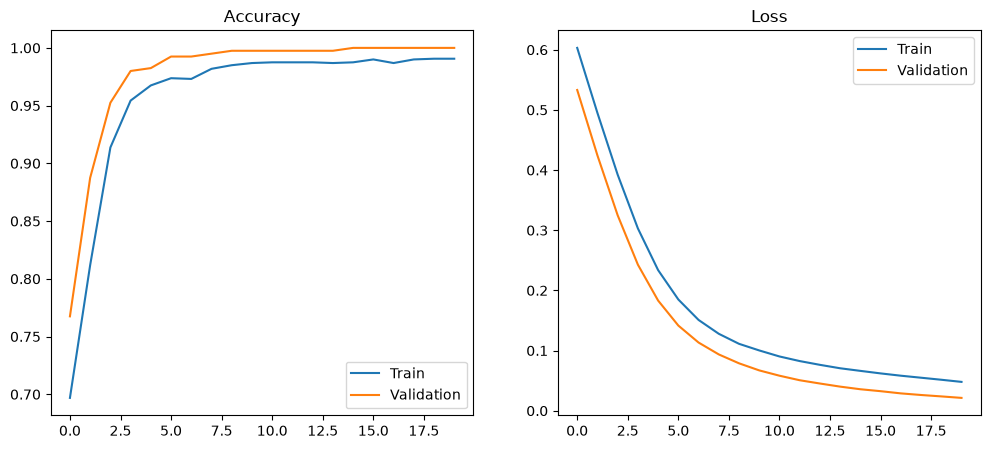

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


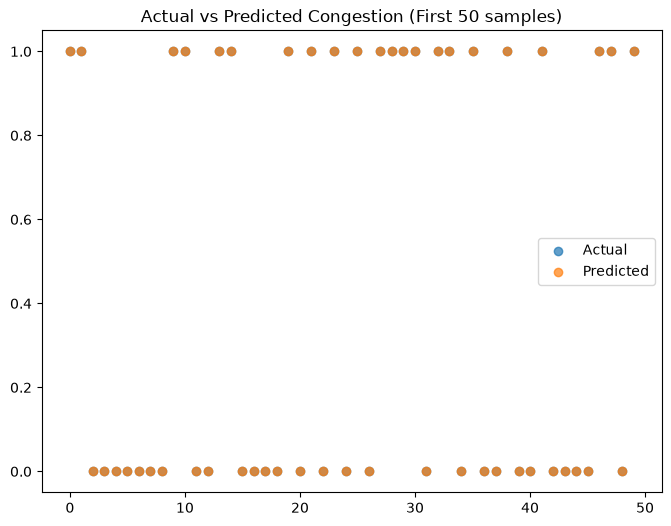

In [9]:
import matplotlib.pyplot as plt

# 학습 곡선
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

# 실제 vs 예측 비교 (테스트 데이터 일부)
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
plt.figure(figsize=(8, 6))
plt.scatter(range(50), y_test[:50], label='Actual', alpha=0.7)
plt.scatter(range(50), y_pred[:50], label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Congestion (First 50 samples)')
plt.legend()
plt.show()

## congetion_occur 컬럼 데이터 변경

In [10]:
# 단순 규칙으로 정확도 100% -> 현실적인 노이즈 추가
# 혼잡도와 배터리에 비례해서 정체 '확률'이 올라가도록 수정

# 기본 정체 확률 계산 (0~1 사이 값)
congestion_probability = (
    df["Current_Traffic"] * 0.08 + (100 - df["Battery_Level"]) * 0.002
)
# 확률이 1을 넘지 않도록 제한
congestion_probability = np.clip(congestion_probability, 0, 0.95)

# 계산된 확률을 기반으로 랜덤하게 0과 1을 부여 (현실적인 예외 상황 발생)
df["Congestion_Occur"] = np.random.binomial(1, congestion_probability)

# 정체 발생 비율 확인
print(df["Congestion_Occur"].value_counts())


Congestion_Occur
1    1090
0     910
Name: count, dtype: int64


In [11]:
df.head(10)

,Timestamp,OHT_ID,Line_No,Current_Traffic,Load_Weight,Battery_Level,Congestion_Occur
0,2026-06-17 09:00:00,OHT_139,5,8,14.41,53,1
1,2026-06-17 09:00:15,OHT_129,3,3,6.74,94,0
2,2026-06-17 09:00:30,OHT_115,3,5,9.72,26,1
3,2026-06-17 09:00:45,OHT_143,1,3,5.91,48,0
4,2026-06-17 09:01:00,OHT_108,1,10,11.26,85,0
5,2026-06-17 09:01:15,OHT_121,1,3,10.51,89,1
6,2026-06-17 09:01:30,OHT_139,2,3,9.07,45,0
7,2026-06-17 09:01:45,OHT_119,4,7,10.21,76,1
8,2026-06-17 09:02:00,OHT_123,2,7,13.97,27,0
9,2026-06-17 09:02:15,OHT_111,4,7,6.96,45,1


## 모델

In [12]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. 딥러닝 학습에 불필요한 문자열/시계열 컬럼 제외하고 Feature(X)와 Target(Y) 분리
X = df[["Line_No", "Current_Traffic", "Load_Weight", "Battery_Level"]]
y = df["Congestion_Occur"]

# 2. train,test로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 데이터 스케일링 (모델의 안정성을 위해)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. 텐서플로우 순차형(Sequential) 딥러닝 모델 설계
model = tf.keras.Sequential(
    [
        # 입력 레이어 + 첫 번째 은닉층 (노드 16개, 활성화함수 ReLU)
        tf.keras.layers.Dense(
            16, activation="relu", input_shape=(X_train.shape[1],)
        ),
        # 두 번째 은닉층 (노드 8개, 활성화함수 ReLU)
        tf.keras.layers.Dense(8, activation="relu"),
        # 출력 레이어 (정체 발생 확률 0~1 사이를 뱉는 Sigmoid 사용)
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ]
)

# 5. 모델 컴파일 (이진 분류에 최적화된 손실함수와 옵티마이저 설정)
model.compile(
    optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]
)

# 6. 딥러닝 모델 학습 시작 (에포크 20회 반복)
print("=== AMHS 정체 예측 모델 학습 시작 ===")
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
)

# 7. 최종 검증 성능 평가
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"검증 정확도(Accuracy): {accuracy*100:.2f}%")


=== AMHS 정체 예측 모델 학습 시작 ===
Epoch 1/20


/home/user/personal/oht/pred/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5450 - loss: 0.6943 - val_accuracy: 0.5475 - val_loss: 0.6757
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5469 - loss: 0.6551 - val_accuracy: 0.5675 - val_loss: 0.6424
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6094 - loss: 0.6204 - val_accuracy: 0.6775 - val_loss: 0.6176
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7063 - loss: 0.6006 - val_accuracy: 0.7050 - val_loss: 0.6096
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7275 - loss: 0.5916 - val_accuracy: 0.7075 - val_loss: 0.6016
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7369 - loss: 0.5802 - val_accuracy: 0.7075 - val_loss: 0.5938
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7362 - loss: 0.5692 - val_accuracy: 0.7100 - val_loss: 0.5881
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7325 - loss: 0.5610 - val_accuracy: 0.7125 - val_loss: 0.5839
Epo

## 시각화

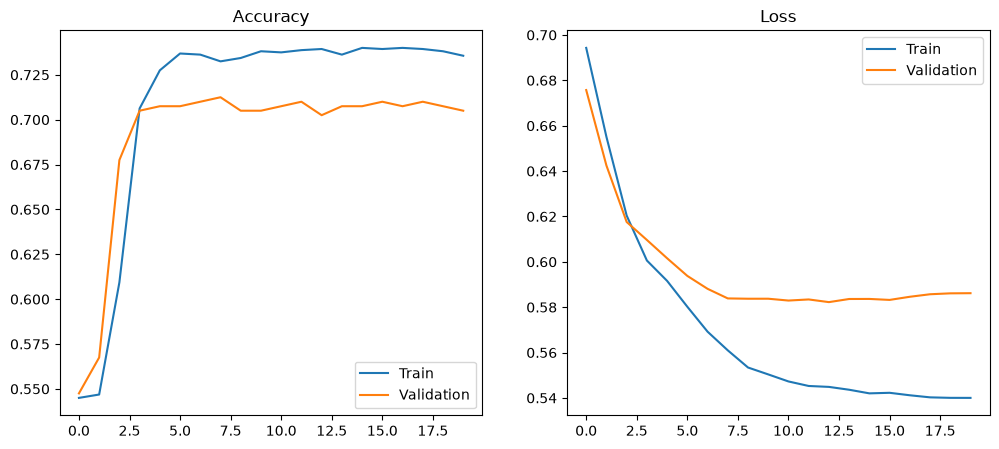

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


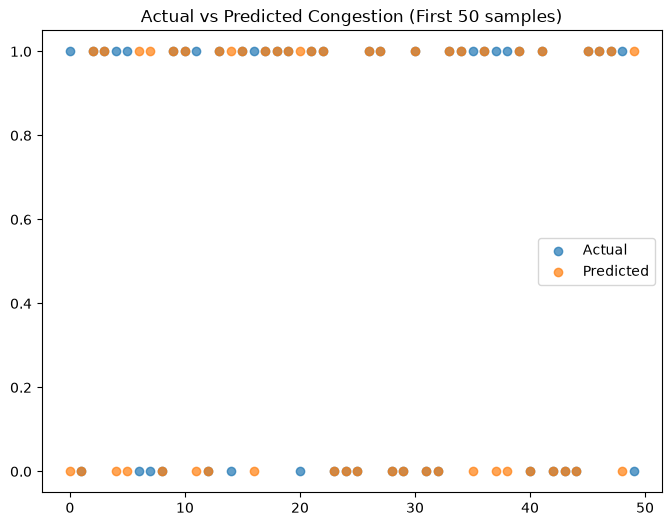

In [13]:
import matplotlib.pyplot as plt

# 학습 곡선
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.legend()
plt.show()

# 실제 vs 예측 비교 (테스트 데이터 일부)
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
plt.figure(figsize=(8, 6))
plt.scatter(range(50), y_test[:50], label='Actual', alpha=0.7)
plt.scatter(range(50), y_pred[:50], label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Congestion (First 50 samples)')
plt.legend()
plt.show()